# 01 — EDA (Telco Customer Churn)

**Leakage rule for this notebook:** we split *first*, then explore **only the training set**.
Every modeling decision (which features matter, how to impute, where thresholds sit) must be
made without ever looking at the test set. The test set is opened exactly once, at final evaluation.

Interview framing: "EDA is part of model development, so it operates under the same
train-only constraint as fitting a scaler."

In [7]:
import sys
sys.path.append("..")  # so `src` imports work from notebooks/

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_raw, make_split, NUMERIC_FEATURES, CATEGORICAL_FEATURES

sns.set_theme(style="whitegrid")

df = load_raw("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
X_train, X_test, y_train, y_test = make_split(df)

train = X_train.copy()
train["Churn"] = y_train

print(train.shape)
train.head()

(5634, 20)


,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
3738,35,49.20,1701.65,Male,0,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,0
3151,15,75.10,1151.55,Male,0,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,0
4860,13,40.55,590.35,Male,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,0
3867,26,73.50,1905.70,Female,0,Yes,No,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),0
3810,1,44.55,44.55,Male,0,Yes,Yes,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,0


## 1. Class balance — sets expectations for every metric downstream

In [8]:
churn_rate = y_train.mean()
print(f"Churn rate (train): {churn_rate:.1%}")
# ~26.5% positive. Consequences:
# - Accuracy is misleading (a 'predict No always' model scores ~73.5%).
# - This is why the project spec uses ROC-AUC, F1, and the PR curve.
# - Baseline for the PR curve = this churn rate, not 0.5.

Churn rate (train): 26.5%


## 2. Missing values — confirm the TotalCharges story

In [9]:
print(train.isna().sum()[lambda s: s > 0])
# Verify the hypothesis: NaN TotalCharges <=> tenure == 0
train.loc[train["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]

TotalCharges    8
dtype: int64


,tenure,MonthlyCharges,TotalCharges
6670,0,73.35,NaN
4380,0,20.00,NaN
3826,0,25.35,NaN
488,0,52.55,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
6754,0,61.90,NaN
3331,0,19.85,NaN


## 3. Numeric features vs churn

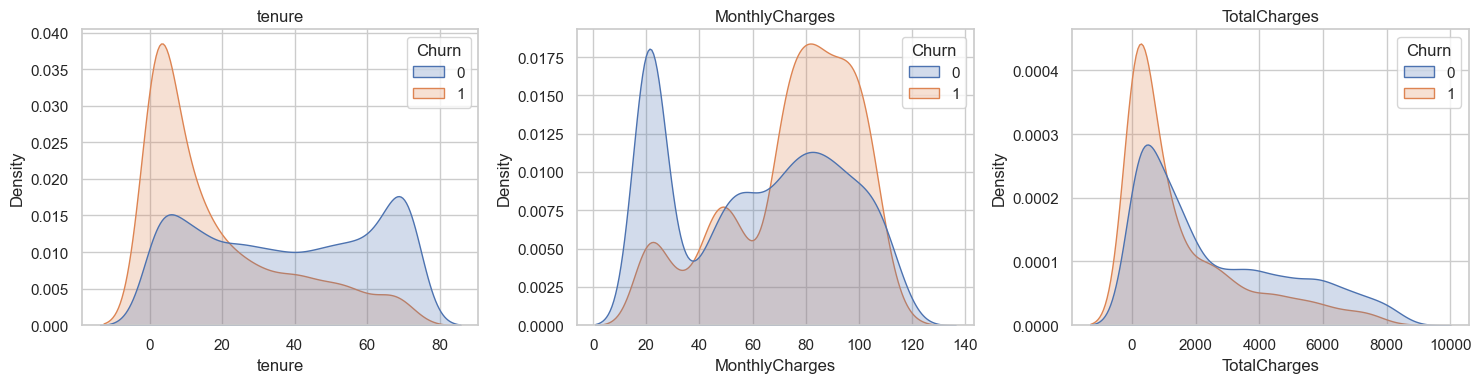

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.kdeplot(data=train, x=col, hue="Churn", common_norm=False, fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
# Expected findings to note in README:
# - Low tenure -> much higher churn (biggest signal in the dataset)
# - Higher MonthlyCharges -> more churn
# - TotalCharges ~ tenure * MonthlyCharges (near-redundant; fine for trees,
#   worth mentioning as multicollinearity for LogReg coefficients)

## 4. Categorical features — churn rate per category

In [11]:
rates = (
    pd.concat(
        [train.groupby(c)["Churn"].mean().rename("rate").reset_index().assign(feature=c).rename(columns={c: "value"})
         for c in CATEGORICAL_FEATURES]
    )
)
top = rates.sort_values("rate", ascending=False).head(12)
display(top)
# Expect month-to-month contract, electronic check payment, and fiber optic
# internet near the top — these become your interview talking points about
# what drives churn.

,value,rate,feature
2,Electronic check,0.457430,PaymentMethod
0,Month-to-month,0.427466,Contract
1,Fiber optic,0.420862,InternetService
0,No,0.419378,OnlineSecurity
0,No,0.417539,TechSupport
1,1,0.410870,SeniorCitizen
0,No,0.401310,OnlineBackup
0,No,0.389563,DeviceProtection
1,Yes,0.338037,PaperlessBilling
0,No,0.336040,StreamingMovies


## 5. Takeaways feeding the pipeline design

1. **Imputation needed** for `TotalCharges` (median imputer in the numeric branch).
2. **Scaling needed** for LogReg (numeric ranges differ by orders of magnitude); trees don't care, but one shared pipeline keeps the code simple and scaling is harmless to trees.
3. **One-hot encoding** for all categoricals — low cardinality throughout, so no dimensionality blow-up.
4. **Class imbalance** is moderate, not extreme: start with `class_weight="balanced"` / `scale_pos_weight` rather than resampling. Justify with the PR curve later.
5. No feature is a leak (nothing here is recorded *after* the churn event) — worth stating explicitly in the README because interviewers ask.